# 09 - Customer Segmentation

Customer segmentation with K-Means to describe behavior, engagement, and customer value. Churned is used only after clustering to profile segments, never as a K-Means input.

Feature contract: explicitly select features from the four spec groups and validate against the engineered dataset and metadata; do not automatically include every numeric column.

## SECTION 01 - Configuration and Reproducibility

In [2]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
MIN_K, MAX_K = 2, 6
N_INIT = 10
PCA_COMPONENTS = 2
SILHOUETTE_SAMPLE_SIZE = 2_000
TARGET = 'Churned'
assert RANDOM_STATE == 42 and MIN_K >= 2 and MAX_K > MIN_K

DATA_FILE = Path('data/processed/customer_churn_feature_engineered.csv')
PROJECT_ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / DATA_FILE).is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError(f'Could not locate {DATA_FILE} from the notebook working directory.')
DATA_PATH = PROJECT_ROOT / DATA_FILE
SEGMENTATION_DIR = PROJECT_ROOT / 'models' / 'segmentation'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'segmentation'
SEGMENTATION_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Random state: {RANDOM_STATE}\nK range: {MIN_K} to {MAX_K}\nClustering algorithm: K-Means\nScaler: StandardScaler')

Random state: 42
K range: 2 to 6
Clustering algorithm: K-Means
Scaler: StandardScaler


## SECTION 02 - Load Dataset and Metadata


In [3]:
df = pd.read_csv(DATA_PATH)
if not df.index.is_unique:
    raise ValueError('Dataset row index must be unique.')
if TARGET not in df or df[TARGET].isna().any() or not set(df[TARGET].unique()).issubset({0, 1}):
    raise ValueError('Churned must exist and contain non-null binary values 0/1.')
metadata_path = PROJECT_ROOT / 'models' / 'preprocessor_metadata.json'
metadata_numeric_features = []
if metadata_path.is_file():
    with metadata_path.open(encoding='utf-8') as f:
        preprocessor_metadata = json.load(f)
    metadata_numeric_features = preprocessor_metadata.get('numeric_features', [])
    if metadata_numeric_features:
        actual_numeric = set(df.select_dtypes(include=np.number).columns) - {TARGET}
        if actual_numeric != set(metadata_numeric_features):
            raise ValueError('Numeric feature columns differ from preprocessor_metadata.json.')
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns; numeric feature contract: {len(metadata_numeric_features)}')


Dataset: 50,000 rows x 33 columns; numeric feature contract: 25


## SECTION 03 - Validate Dataset and Segmentation Contract


In [4]:
FORBIDDEN_FEATURES = {
    'Churned', 'Customer_ID', 'Churn_Probability', 'Churn_Risk_Score', 'Churn_Risk',
    'Churn_Status', 'Churn_Level', 'Churned_Score', 'SHAP_Value', 'Prediction', 'Segment',
}


## SECTION 04 - Explicit Segmentation Features


In [5]:
#17 explicitly selected spec features from the dataset's 25 numeric predictors.
# Engineered interaction/group features are not selected as they duplicate underlying behavior.
SEGMENTATION_FEATURES = [
    # Engagement
    'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Email_Open_Rate',
    'Mobile_App_Usage', 'Social_Media_Engagement_Score',
    # Purchase behavior
    'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
    'Cart_Abandonment_Rate', 'Discount_Usage_Rate', 'Returns_Rate',
    # Relationship
    'Membership_Years', 'Customer_Service_Calls', 'Product_Reviews_Written',
    # Customer value
    'Lifetime_Value', 'Credit_Balance',
]
missing_features = sorted(set(SEGMENTATION_FEATURES) - set(df.columns))
if missing_features:
    raise KeyError(f'Required segmentation features missing: {missing_features}')
if len(SEGMENTATION_FEATURES) != len(set(SEGMENTATION_FEATURES)):
    raise ValueError('SEGMENTATION_FEATURES contains duplicates.')
forbidden_used = set(SEGMENTATION_FEATURES) & FORBIDDEN_FEATURES
if forbidden_used:
    raise ValueError(f'Forbidden features detected in clustering inputs: {sorted(forbidden_used)}')
for feature in SEGMENTATION_FEATURES:
    if metadata_numeric_features and feature not in metadata_numeric_features:
        raise ValueError(f'{feature} is not numeric in the preprocessing metadata.')
print(f'Explicit clustering features ({len(SEGMENTATION_FEATURES)}): {SEGMENTATION_FEATURES}')
assert TARGET not in SEGMENTATION_FEATURES
assert 'Segment' not in SEGMENTATION_FEATURES

Explicit clustering features (17): ['Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Email_Open_Rate', 'Mobile_App_Usage', 'Social_Media_Engagement_Score', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Cart_Abandonment_Rate', 'Discount_Usage_Rate', 'Returns_Rate', 'Membership_Years', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Lifetime_Value', 'Credit_Balance']


## SECTION 05 - Prepare Clustering Data


In [6]:
X_cluster = df[SEGMENTATION_FEATURES].copy()
if len(X_cluster.select_dtypes(exclude=np.number).columns):
    raise TypeError('Every clustering feature must be numeric.')
X_cluster = X_cluster.astype(float).replace([np.inf, -np.inf], np.nan)
all_missing_features = X_cluster.columns[X_cluster.isna().all()].tolist()
X_cluster = X_cluster.drop(columns=all_missing_features)
constant_features = X_cluster.columns[X_cluster.nunique(dropna=True) <= 1].tolist()
X_cluster = X_cluster.drop(columns=constant_features)
if X_cluster.shape[1] < 2:
    raise ValueError('At least two non-constant numeric features are required.')
missing_count = int(X_cluster.isna().sum().sum())
imputer = SimpleImputer(strategy='median') if missing_count else None
if imputer is not None:
    X_cluster = pd.DataFrame(imputer.fit_transform(X_cluster), index=X_cluster.index, columns=X_cluster.columns)
if not np.isfinite(X_cluster.to_numpy()).all():
    raise ValueError('NaN/Inf remains after data preparation.')
print(f'Dropped all-missing features: {all_missing_features}')
print(f'Dropped constant features: {constant_features}')
print(f'Median imputation used: {imputer is not None}; missing cells before imputation: {missing_count}')


Dropped all-missing features: []
Dropped constant features: []
Median imputation used: False; missing cells before imputation: 0


## SECTION 06 - Standardize Clustering Features


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
if not np.isfinite(X_scaled).all():
    raise ValueError('StandardScaler produced non-finite values.')
print(f'Scaled matrix: {X_scaled.shape}; mean={X_scaled.mean():.5f}; std={X_scaled.std():.5f}')


Scaled matrix: (50000, 17); mean=0.00000; std=1.00000


## SECTION 07 - Determine Optimal K with Elbow and Silhouette


,K,Inertia,Silhouette,Smallest_Segment_Percentage,Inertia_Reduction_Percentage
0,2,621604.075103,0.267559,37.012,NaN
1,3,566310.443876,0.145551,18.590,8.895314
2,4,544332.440646,0.097055,11.210,3.880911
3,5,499189.100932,0.097494,0.050,8.293340
4,6,471136.298495,0.099383,0.050,5.619674


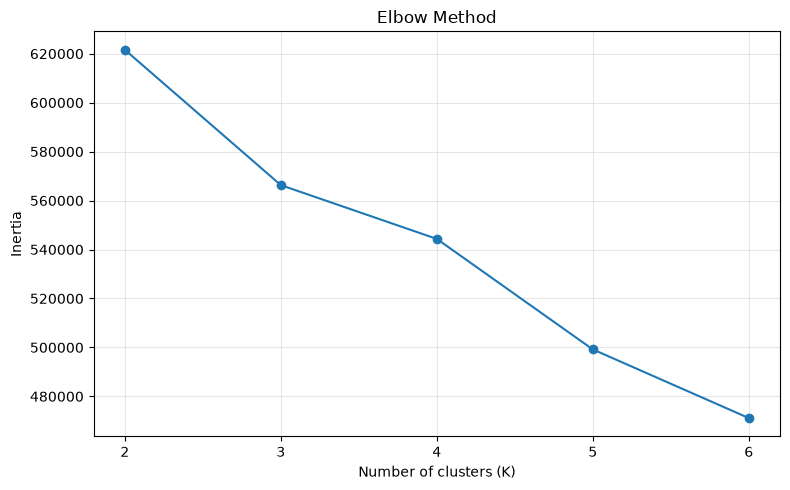

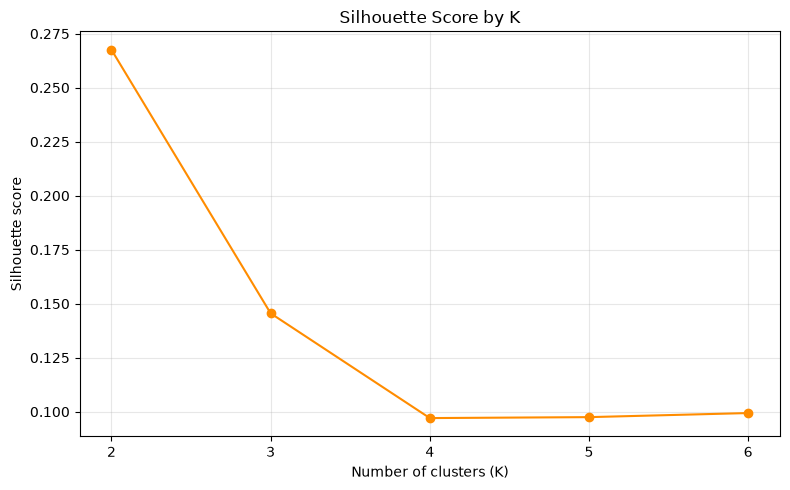

Select K using statistical quality + elbow behavior + segment size + business interpretability; do not use silhouette alone.


In [8]:
k_rows = []
for k in range(MIN_K, MAX_K + 1):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
    labels = model.fit_predict(X_scaled)
    sample_size = min(SILHOUETTE_SAMPLE_SIZE, len(X_scaled))
    score = silhouette_score(X_scaled, labels, sample_size=sample_size, random_state=RANDOM_STATE)
    smallest_share = pd.Series(labels).value_counts(normalize=True).min() * 100
    k_rows.append({'K': k, 'Inertia': float(model.inertia_), 'Silhouette': float(score), 'Smallest_Segment_Percentage': float(smallest_share)})
k_evaluation = pd.DataFrame(k_rows)
k_evaluation['Inertia_Reduction_Percentage'] = (k_evaluation['Inertia'].shift() - k_evaluation['Inertia']) / k_evaluation['Inertia'].shift() * 100
display(k_evaluation)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_evaluation['K'], k_evaluation['Inertia'], marker='o')
ax.set(title='Elbow Method', xlabel='Number of clusters (K)', ylabel='Inertia')
ax.set_xticks(range(MIN_K, MAX_K + 1))
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_evaluation['K'], k_evaluation['Silhouette'], marker='o', color='darkorange')
ax.set(title='Silhouette Score by K', xlabel='Number of clusters (K)', ylabel='Silhouette score')
ax.set_xticks(range(MIN_K, MAX_K + 1))
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Select K using statistical quality + elbow behavior + segment size + business interpretability; do not use silhouette alone.')


## SECTION 08 - Train Final K-Means


In [9]:
# This setting is selected after reviewing the K evaluation table and plots above.
FINAL_K = 2
if FINAL_K not in range(MIN_K, MAX_K + 1):
    raise ValueError('FINAL_K is outside the evaluated range.')
final_kmeans = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=N_INIT)
segment_labels = final_kmeans.fit_predict(X_scaled)
if len(segment_labels) != len(df) or set(segment_labels) != set(range(FINAL_K)):
    raise ValueError('Final labels do not match dataset size or selected K.')


## SECTION 09 - Assign Customers to Segments


In [10]:
segmented_df = df.copy()
segmented_df['Customer_Row_Index'] = df.index
segmented_df['Segment'] = segment_labels
if 'Customer_ID' in df.columns:
    segmented_df['Customer_Identifier'] = df['Customer_ID']

## SECTION 10 - Build Segment Profiles and Feature Summary


In [11]:
profile_rows = []
for segment, group in segmented_df.groupby('Segment', sort=True):
    row = {
        'Segment': int(segment),
        'Customer_Count': int(len(group)),
        'Customer_Percentage': float(len(group) / len(df) * 100),
        'Churned_Count': int(group[TARGET].sum()),
        'Churn_Rate': float(group[TARGET].mean()),
        'Avg_Lifetime_Value': float(group['Lifetime_Value'].mean()),
        'Avg_Engagement_Score': float(group['Engagement_Score'].mean()) if 'Engagement_Score' in group else np.nan,
    }
    row.update({f'Avg_{feature}': float(group[feature].mean()) for feature in X_cluster.columns})
    profile_rows.append(row)
segment_profile = pd.DataFrame(profile_rows)
if segment_profile['Customer_Count'].sum() != len(df):
    raise ValueError('Segment customer counts do not sum to the dataset row count.')
feature_summary = segmented_df.groupby('Segment')[X_cluster.columns.tolist()].agg(['mean', 'median', 'std'])
feature_summary.columns = [f'{feature}_{stat}' for feature, stat in feature_summary.columns]
feature_summary = feature_summary.reset_index()
display(segment_profile)
display(feature_summary)

,Segment,Customer_Count,Customer_Percentage,Churned_Count,Churn_Rate,Avg_Lifetime_Value,Avg_Engagement_Score,Avg_Login_Frequency,Avg_Session_Duration_Avg,Avg_Pages_Per_Session,...,Avg_Total_Purchases,Avg_Average_Order_Value,Avg_Days_Since_Last_Purchase,Avg_Cart_Abandonment_Rate,Avg_Discount_Usage_Rate,Avg_Returns_Rate,Avg_Membership_Years,Avg_Customer_Service_Calls,Avg_Product_Reviews_Written,Avg_Credit_Balance
0,0,18506,37.012,3787,0.204636,2102.157397,0.440655,18.471144,37.393094,11.994256,...,19.031449,127.421947,29.61780,43.075408,41.638370,6.809230,2.991471,4.242732,4.462607,2745.501243
1,1,31494,62.988,10663,0.338572,1051.907976,0.218525,7.601638,21.849095,6.792132,...,9.655395,120.587920,29.05817,65.250470,41.568317,6.422857,2.979625,6.523814,1.812853,1496.066997


,Segment,Login_Frequency_mean,Login_Frequency_median,Login_Frequency_std,Session_Duration_Avg_mean,Session_Duration_Avg_median,Session_Duration_Avg_std,Pages_Per_Session_mean,Pages_Per_Session_median,Pages_Per_Session_std,...,Customer_Service_Calls_std,Product_Reviews_Written_mean,Product_Reviews_Written_median,Product_Reviews_Written_std,Lifetime_Value_mean,Lifetime_Value_median,Lifetime_Value_std,Credit_Balance_mean,Credit_Balance_median,Credit_Balance_std
0,0,18.471144,18.0,6.455070,37.393094,36.6,8.189897,11.994256,11.8,2.942904,...,2.183424,4.462607,4.0,2.376488,2102.157397,1913.11,964.244066,2745.501243,2655.0,1075.195741
1,1,7.601638,7.0,5.351797,21.849095,22.4,6.789782,6.792132,6.9,2.491615,...,2.570306,1.812853,2.0,1.471875,1051.907976,939.08,593.454393,1496.066997,1571.0,929.667215


## SECTION 11 - Churn, LTV, Engagement, and Business Priority


In [12]:
overall_churn = float(segmented_df[TARGET].mean())
ltv_reference = float(segment_profile['Avg_Lifetime_Value'].median())
engagement_reference = segment_profile['Avg_Engagement_Score'].median()
def interpret_segment(row):
    high_churn = row['Churn_Rate'] >= overall_churn
    high_ltv = row['Avg_Lifetime_Value'] >= ltv_reference
    high_engagement = pd.notna(engagement_reference) and row['Avg_Engagement_Score'] >= engagement_reference
    if high_churn and high_ltv:
        name, priority, action = 'High-Value At-Risk Customers', 'VERY HIGH', 'Prioritize personalized retention outreach.'
    elif high_churn:
        name, priority, action = 'At-Risk Customers', 'HIGH', 'Investigate friction and test targeted retention offers.'
    elif high_ltv:
        name = 'Loyal High-Value Customers' if high_engagement else 'High-Value Customers'
        priority, action = 'MAINTAIN', 'Protect loyalty with relevant benefits and maintain engagement.'
    else:
        name = 'Engaged Growth Customers' if high_engagement else 'Stable Customers'
        priority, action = 'LOW', 'Use cost-effective engagement and growth campaigns.'
    return pd.Series({
        'Segment_Name': f'{name} (Segment {int(row["Segment"])})',
        'Business_Priority': priority,
        'Recommended_Action': action,
        'Churn_Level': 'High' if high_churn else 'Low',
        'Value_Level': 'High' if high_ltv else 'Low',
        'Engagement_Level': 'High' if high_engagement else 'Low',
    })
segment_profile = pd.concat([segment_profile, segment_profile.apply(interpret_segment, axis=1)], axis=1)
segment_profile['Retention_Priority_Score'] = segment_profile['Churn_Rate'] * segment_profile['Customer_Count'] * segment_profile['Avg_Lifetime_Value'].fillna(0)
segment_profile['Retention_Priority_Rank'] = segment_profile['Retention_Priority_Score'].rank(method='dense', ascending=False).astype(int)
display(segment_profile[['Segment', 'Segment_Name', 'Customer_Count', 'Customer_Percentage', 'Churned_Count', 'Churn_Rate', 'Avg_Lifetime_Value', 'Avg_Engagement_Score', 'Business_Priority', 'Retention_Priority_Score', 'Retention_Priority_Rank', 'Recommended_Action']])
print('Highest churn segment:', int(segment_profile.loc[segment_profile['Churn_Rate'].idxmax(), 'Segment']))
print('Highest LTV segment:', int(segment_profile.loc[segment_profile['Avg_Lifetime_Value'].idxmax(), 'Segment']))
print('Top retention priority:', int(segment_profile.loc[segment_profile['Retention_Priority_Score'].idxmax(), 'Segment']))


,Segment,Segment_Name,Customer_Count,Customer_Percentage,Churned_Count,Churn_Rate,Avg_Lifetime_Value,Avg_Engagement_Score,Business_Priority,Retention_Priority_Score,Retention_Priority_Rank,Recommended_Action
0,0,Loyal High-Value Customers (Segment 0),18506,37.012,3787,0.204636,2102.157397,0.440655,MAINTAIN,7.960870e+06,2,Protect loyalty with relevant benefits and mai...
1,1,At-Risk Customers (Segment 1),31494,62.988,10663,0.338572,1051.907976,0.218525,HIGH,1.121649e+07,1,Investigate friction and test targeted retenti...


Highest churn segment: 1
Highest LTV segment: 0
Top retention priority: 1


## SECTION 12 - Segment Visualization


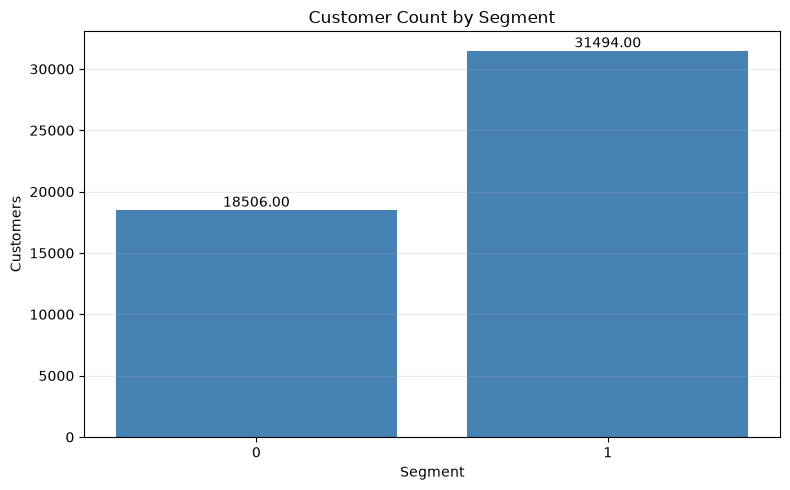

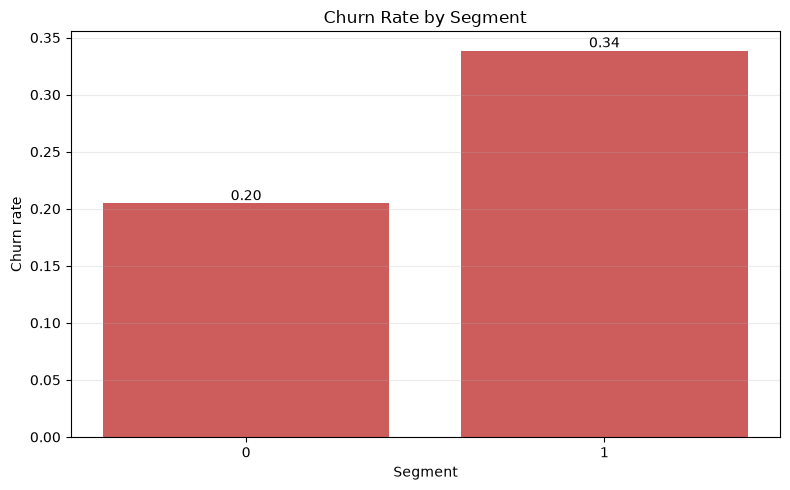

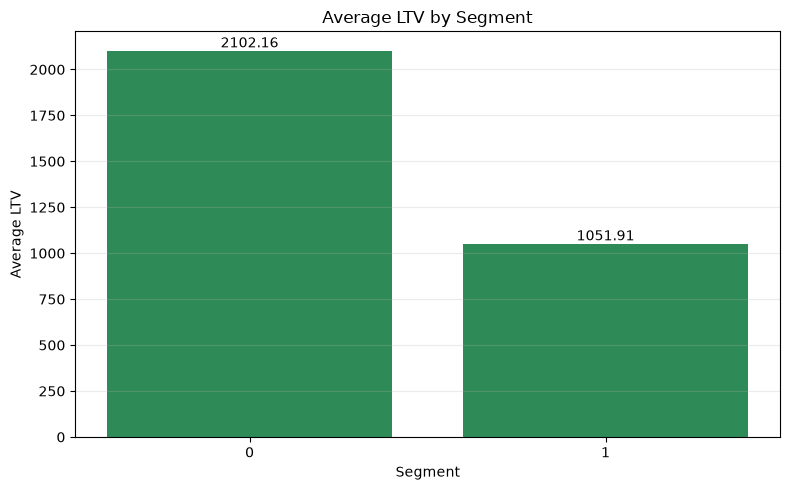

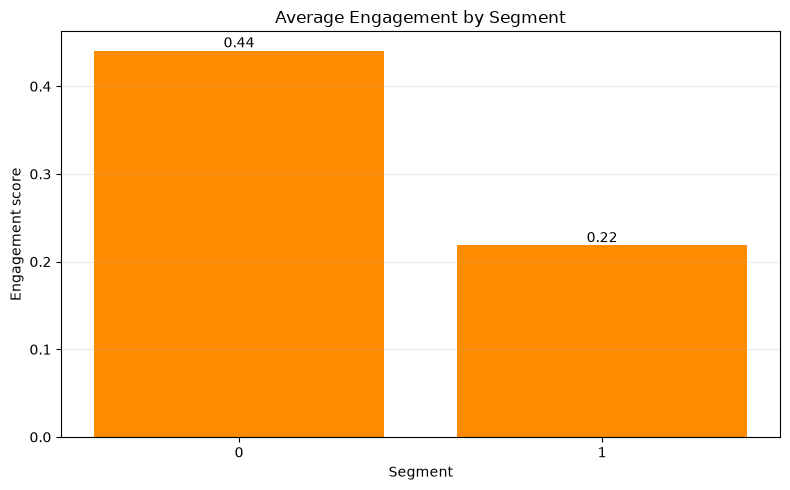

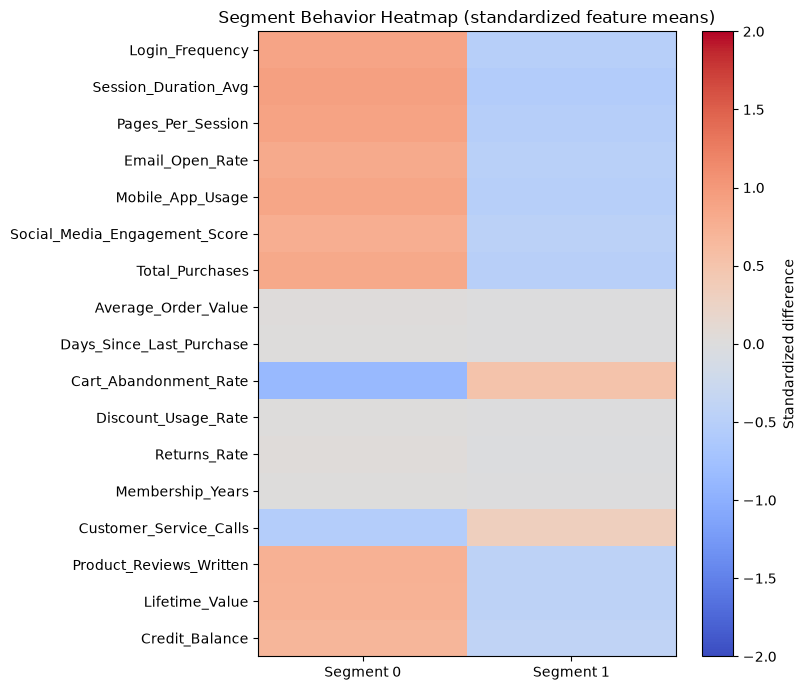

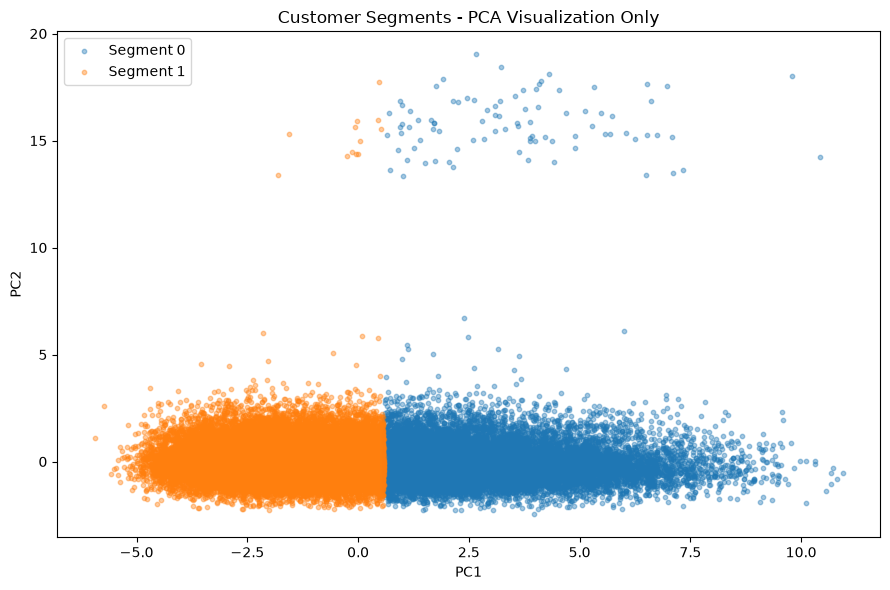

In [13]:
def save_segment_bar(metric, title, ylabel, filename, color):
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(segment_profile['Segment'].astype(str), segment_profile[metric], color=color)
    ax.set(title=title, xlabel='Segment', ylabel=ylabel)
    ax.bar_label(bars, fmt='%.2f')
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
save_segment_bar('Customer_Count', 'Customer Count by Segment', 'Customers', 'segment_distribution.png', 'steelblue')
save_segment_bar('Churn_Rate', 'Churn Rate by Segment', 'Churn rate', 'churn_rate_by_segment.png', 'indianred')
save_segment_bar('Avg_Lifetime_Value', 'Average LTV by Segment', 'Average LTV', 'ltv_by_segment.png', 'seagreen')
save_segment_bar('Avg_Engagement_Score', 'Average Engagement by Segment', 'Engagement score', 'engagement_by_segment.png', 'darkorange')
segment_means = segmented_df.groupby('Segment')[X_cluster.columns].mean()
heatmap = ((segment_means - X_cluster.mean()) / X_cluster.std().replace(0, np.nan)).T.fillna(0)
fig, ax = plt.subplots(figsize=(8, max(7, len(heatmap) * 0.38)))
image = ax.imshow(heatmap, aspect='auto', cmap='coolwarm', vmin=-2, vmax=2)
ax.set_yticks(range(len(heatmap.index)), labels=heatmap.index)
ax.set_xticks(range(FINAL_K), labels=[f'Segment {k}' for k in range(FINAL_K)])
ax.set_title('Segment Behavior Heatmap (standardized feature means)')
fig.colorbar(image, ax=ax, label='Standardized difference')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'segment_behavior_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
# PCA is only for visualization; K-Means uses the complete X_scaled matrix.
pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(9, 6))
for segment in range(FINAL_K):
    mask = segment_labels == segment
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.4, label=f'Segment {segment}')
ax.set(title='Customer Segments - PCA Visualization Only', xlabel='PC1', ylabel='PC2')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'segment_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 13 - Segment-Level SHAP Integration


In [14]:
shap_path = PROJECT_ROOT / 'models' / 'shap' / 'shap_local_explanations.csv'

# SHAP artifact is required for the segmentation pipeline
if not shap_path.is_file():
    raise FileNotFoundError(
        f"Required SHAP artifact not found: {shap_path}"
    )

shap_local = pd.read_csv(shap_path)

# Validate SHAP artifact schema
required_shap = {
    'Customer_Row_Index',
    'Feature',
    'SHAP_Value'
}

if not required_shap.issubset(shap_local.columns):
    raise ValueError(
        f"SHAP artifact schema mismatch. "
        f"Required columns: {required_shap}. "
        f"Found columns: {set(shap_local.columns)}"
    )

# Merge SHAP explanations with customer segments
shap_by_segment = shap_local.merge(
    segmented_df[['Customer_Row_Index', 'Segment']],
    on='Customer_Row_Index',
    how='inner',
    validate='many_to_one'
)

if shap_by_segment.empty:
    raise ValueError(
        "SHAP rows did not match dataset row identifiers."
    )

# Calculate mean absolute SHAP value by segment and feature
shap_by_segment['Mean_Abs_SHAP'] = (
    shap_by_segment['SHAP_Value'].abs()
)

shap_by_segment = (
    shap_by_segment
    .groupby(
        ['Segment', 'Feature'],
        as_index=False
    )['Mean_Abs_SHAP']
    .mean()
    .sort_values(
        ['Segment', 'Mean_Abs_SHAP'],
        ascending=[True, False]
    )
)

# Save segment-level SHAP summary
shap_by_segment.to_csv(
    SEGMENTATION_DIR / 'segment_shap_summary.csv',
    index=False
)

# Display top SHAP features for each segment
display(
    shap_by_segment
    .groupby('Segment', group_keys=False)
    .head(5)
)

print(
    'SHAP describes model contribution, not causal effect.'
)

,Segment,Feature,Mean_Abs_SHAP
34,0,num__Customer_Service_Calls,1.756574
40,0,num__Lifetime_Value,1.200479
31,0,num__Cart_Abandonment_Rate,0.276876
32,0,num__Cart_Recency_Interaction,0.267695
50,0,num__Session_Duration_Avg,0.247227


SHAP describes model contribution, not causal effect.


## SECTION 14 - Save Artifacts and Final Validation


In [15]:
customer_segments = segmented_df[['Customer_Row_Index', 'Segment', TARGET]].copy()
if 'Customer_Identifier' in segmented_df:
    customer_segments.insert(1, 'Customer_Identifier', segmented_df['Customer_Identifier'])
for column in ('Lifetime_Value', 'Engagement_Score'):
    if column in segmented_df:
        customer_segments[column] = segmented_df[column]
customer_segments.to_csv(SEGMENTATION_DIR / 'customer_segments.csv', index=False)
segment_profile.to_csv(SEGMENTATION_DIR / 'segment_profile.csv', index=False)
feature_summary.to_csv(SEGMENTATION_DIR / 'segment_feature_summary.csv', index=False)
joblib.dump(final_kmeans, SEGMENTATION_DIR / 'kmeans.joblib')
joblib.dump(scaler, SEGMENTATION_DIR / 'segmentation_scaler.joblib')
joblib.dump(imputer, SEGMENTATION_DIR / 'segmentation_imputer.joblib')
final_silhouette = float(k_evaluation.loc[k_evaluation['K'] == FINAL_K, 'Silhouette'].iloc[0])
selected_row = k_evaluation.loc[k_evaluation['K'] == FINAL_K].iloc[0]
selection_rationale = (
    f"K={FINAL_K} selected after reviewing silhouette, "
    f"inertia/elbow behavior, smallest segment size "
    f"({selected_row['Smallest_Segment_Percentage']:.1f}%), "
    f"and business interpretability."
)
metadata = {
    'random_state': RANDOM_STATE, 'algorithm': 'KMeans', 'selected_k': FINAL_K,
    'min_k': MIN_K, 'max_k': MAX_K, 'n_init': N_INIT, 'scaler': 'StandardScaler',
    'features': X_cluster.columns.tolist(), 'requested_features': SEGMENTATION_FEATURES,
    'dropped_constant_features': constant_features, 'dropped_all_missing_features': all_missing_features,
    'median_imputation_used': imputer is not None,
    'imputer': 'SimpleImputer(strategy="median")' if imputer else None,
    'silhouette_score': final_silhouette,
    'silhouette_sample_size': min(SILHOUETTE_SAMPLE_SIZE, len(X_scaled)),
    'inertia': float(final_kmeans.inertia_), 'dataset_rows': int(len(df)),
    'dataset_columns': int(df.shape[1]), 'numeric_feature_contract_count': len(metadata_numeric_features) or None,
    'k_evaluation': k_evaluation[['K', 'Inertia', 'Silhouette', 'Smallest_Segment_Percentage']].to_dict(orient='records'),
    'selection_rationale': selection_rationale,
    'business_priority_score': 'Churn_Rate * Customer_Count * Avg_Lifetime_Value',
    'business_priority_score_type': 'heuristic',
    'shap_used_for_clustering': False,
}
with (SEGMENTATION_DIR / 'segmentation_metadata.json').open('w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
required_files = [
    'kmeans.joblib', 'segmentation_scaler.joblib', 'segmentation_imputer.joblib',
    'customer_segments.csv', 'segment_profile.csv', 'segment_feature_summary.csv',
    'segment_shap_summary.csv', 'segmentation_metadata.json',
]
required_figures = [
    'elbow_curve.png', 'silhouette_scores.png', 'segment_distribution.png',
    'churn_rate_by_segment.png', 'ltv_by_segment.png', 'engagement_by_segment.png',
    'segment_behavior_heatmap.png', 'segment_pca.png',
]
missing_outputs = [name for name in required_files if not (SEGMENTATION_DIR / name).is_file()]
missing_outputs += [name for name in required_figures if not (FIGURES_DIR / name).is_file()]
if missing_outputs:
    raise FileNotFoundError(f'Required outputs missing: {missing_outputs}')
if TARGET in metadata['features'] or customer_segments['Customer_Row_Index'].duplicated().any() or customer_segments['Segment'].isna().any() or set(customer_segments['Segment'].unique()) != set(range(FINAL_K)):
    raise ValueError('Final leakage or customer-to-segment validation failed.')
print('Validation: PASSED')
print(f'Selected K: {FINAL_K}; silhouette: {final_silhouette:.4f}; inertia: {final_kmeans.inertia_:.2f}')
print(f'Artifacts: {SEGMENTATION_DIR}\nFigures: {FIGURES_DIR}')
display(pd.DataFrame({'Output': required_files + required_figures}))

Validation: PASSED
Selected K: 2; silhouette: 0.2676; inertia: 621604.08
Artifacts: D:\Desktop\Projects\customer-churn-analytics\models\segmentation
Figures: D:\Desktop\Projects\customer-churn-analytics\reports\figures\segmentation


,Output
0,kmeans.joblib
1,segmentation_scaler.joblib
2,segmentation_imputer.joblib
3,customer_segments.csv
4,segment_profile.csv
5,segment_feature_summary.csv
6,segment_shap_summary.csv
7,segmentation_metadata.json
8,elbow_curve.png
9,silhouette_scores.png
